## Imports and Setup


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
import ast
import joblib
from scipy.optimize import differential_evolution

np.random.seed(42)


## Helper Functions


In [69]:
def calculate_spread_and_zscore(price1, price2, lookback=60):
    """
    Calculate spread and z-score for a pair of stocks
    
    Parameters:
    - price1, price2: pandas Series with prices
    - lookback: window for rolling mean/std
    
    Returns:
    - DataFrame with spread, z_score, hedge_ratio, rolling_mean, rolling_std
    """
    # Align data by date
    common_dates = price1.index.intersection(price2.index)
    p1 = price1.loc[common_dates]
    p2 = price2.loc[common_dates]
    
    if len(p1) < lookback + 10:
        return None
    
    # Calculate hedge ratio using OLS regression
    hedge_ratio = linregress(p1.values, p2.values).slope
    
    # Calculate spread: stock2 - hedge_ratio * stock1
    spread = p2 - hedge_ratio * p1
    
    # Rolling statistics
    rolling_mean = spread.rolling(window=lookback).mean()
    rolling_std = spread.rolling(window=lookback).std()
    
    # Z-score
    z_score = (spread - rolling_mean) / rolling_std
    
    return pd.DataFrame({
        'spread': spread,
        'z_score': z_score,
        'hedge_ratio': hedge_ratio,
        'rolling_mean': rolling_mean,
        'rolling_std': rolling_std
    }, index=common_dates)

def create_labels(spread_df, z_threshold=2.0, min_days=5, max_days=10, revert_threshold=0.5):
    """
    Create labels: 1 if spread reverts to mean within 5-10 days, else 0
    
    Parameters:
    - spread_df: DataFrame with 'z_score' column
    - z_threshold: absolute z-score to trigger labeling (e.g., 2.0)
    - min_days, max_days: reversion window (5-10 days)
    - revert_threshold: z-score must return to within this of zero
    
    Returns:
    - Series with labels (1 = reverts, 0 = doesn't revert)
    """
    labels = pd.Series(0, index=spread_df.index)
    z_scores = spread_df['z_score']
    
    for i in range(len(spread_df) - max_days):
        current_z = z_scores.iloc[i]
        
        # Only label if current z-score is extreme
        if abs(current_z) < z_threshold or np.isnan(current_z):
            continue
        
        # Check if z-score returns to near zero within 5-10 days
        future_window = z_scores.iloc[i+min_days:i+max_days+1]
        
        if len(future_window) > 0:
            # Remove NaN values
            future_window_clean = future_window.dropna()
            if len(future_window_clean) > 0:
                # Label = 1 if any future z-score is within revert_threshold of zero
                if np.any(np.abs(future_window_clean) <= revert_threshold):
                    labels.iloc[i] = 1
    
    return labels

def create_pair_features(price1, price2, spread_df):
    """
    Create feature vector for a pair at each time point
    """
    features_list = []
    
    for date in spread_df.index:
        features = {}
        
        # Spread features
        if date in spread_df.index:
            features['spread'] = spread_df.loc[date, 'spread']
            features['z_score'] = spread_df.loc[date, 'z_score']
            features['z_score_abs'] = abs(spread_df.loc[date, 'z_score']) if not np.isnan(spread_df.loc[date, 'z_score']) else np.nan
            features['hedge_ratio'] = spread_df.loc[date, 'hedge_ratio']
            
            # Rolling features
            date_idx = spread_df.index.get_loc(date)
            if date_idx >= 5:
                spread_window_5 = spread_df['spread'].iloc[date_idx-5:date_idx+1]
                z_window_5 = spread_df['z_score'].iloc[date_idx-5:date_idx+1]
                features['spread_ma_5'] = spread_window_5.mean()
                features['spread_std_5'] = spread_window_5.std()
                features['z_score_ma_5'] = z_window_5.mean()
                features['z_score_std_5'] = z_window_5.std()
            else:
                features['spread_ma_5'] = np.nan
                features['spread_std_5'] = np.nan
                features['z_score_ma_5'] = np.nan
                features['z_score_std_5'] = np.nan
            
            if date_idx >= 10:
                spread_window_10 = spread_df['spread'].iloc[date_idx-10:date_idx+1]
                features['spread_ma_10'] = spread_window_10.mean()
            else:
                features['spread_ma_10'] = np.nan
        
        # Price features
        if date in price1.index and date in price2.index:
            # Returns
            p1_returns = price1.pct_change()
            p2_returns = price2.pct_change()
            
            if date in p1_returns.index and not np.isnan(p1_returns.loc[date]):
                features['return1_1d'] = p1_returns.loc[date]
            else:
                features['return1_1d'] = np.nan
                
            if date in p2_returns.index and not np.isnan(p2_returns.loc[date]):
                features['return2_1d'] = p2_returns.loc[date]
            else:
                features['return2_1d'] = np.nan
            
            # Rolling correlation
            if date >= price1.index[min(60, len(price1))]:
                returns1_window = p1_returns.loc[:date].tail(60).dropna()
                returns2_window = p2_returns.loc[:date].tail(60).dropna()
                common_dates_ret = returns1_window.index.intersection(returns2_window.index)
                if len(common_dates_ret) > 10:
                    features['correlation_60d'] = returns1_window.loc[common_dates_ret].corr(returns2_window.loc[common_dates_ret])
                else:
                    features['correlation_60d'] = np.nan
            else:
                features['correlation_60d'] = np.nan
        else:
            features['return1_1d'] = np.nan
            features['return2_1d'] = np.nan
            features['correlation_60d'] = np.nan
        
        features_list.append(features)
    
    return pd.DataFrame(features_list, index=spread_df.index)



## Stage 5: Using Stage 4 ML Discovery Data


## Load Stage 4 Candidate Pairs


In [ ]:
candidate_pairs = pd.read_csv('./dataset/cluster_candidate_pairs.csv')

print("Loaded Stage 4 candidate pairs:", len(candidate_pairs))
print("Pair statistics:")
print("Total pairs:", len(candidate_pairs))
print("Same-sector pairs:", candidate_pairs['same_sector'].sum(), "(" + str(candidate_pairs['same_sector'].mean()*100) + "%)")
print("Average embedding distance:", candidate_pairs['embedding_distance'].mean())

q = 0.15
threshold = candidate_pairs['embedding_distance'].quantile(q)
print(f"Using empirical distance threshold at {int(q*100)}th percentile:")
print("  embedding_distance <=", threshold)

filtered = candidate_pairs[
    (candidate_pairs['same_sector'] == True) &
    (candidate_pairs['embedding_distance'] <= threshold)
]

N = 100
top_pairs = filtered.nsmallest(N, 'embedding_distance')

print("Selected top", len(top_pairs), "pairs for Stage 5 analysis")
print("Average embedding distance of selected pairs:", top_pairs['embedding_distance'].mean())

Loaded Stage 4 candidate pairs: 22034
Pair statistics:
Total pairs: 22034
Same-sector pairs: 4042 (18.344376872106743%)
Average embedding distance: 74.14609768131729
Using empirical distance threshold at 15th percentile:
  embedding_distance <= 48.852819908793386
Selected top 100 pairs for Stage 5 analysis
Average embedding distance of selected pairs: 14.649926106053424


## Load Price Data


In [ ]:
# Process each pair and collect features/labels
all_features = []
all_labels = []
pair_info = []

min_days = 5
max_days = 10

for idx, row in top_pairs.iterrows():
    ticker1, ticker2 = row['ticker1'], row['ticker2']
    
    # Get prices
    if ticker1 not in prices.columns or ticker2 not in prices.columns:
        continue
        
    price1 = prices[ticker1].dropna()
    price2 = prices[ticker2].dropna()
    
    if len(price1) < 100 or len(price2) < 100:
        continue
    
    # Calculate spread
    spread_df = calculate_spread_and_zscore(price1, price2)
    
    if spread_df is None or len(spread_df) < max_days + 10:
        continue
    
    # Create labels
    labels = create_labels(spread_df, min_days=min_days, max_days=max_days)
    
    # Create features
    features = create_pair_features(price1, price2, spread_df)
    
    # Store pair info
    features['ticker1'] = ticker1
    features['ticker2'] = ticker2
    features['pair_id'] = ticker1 + "_" + ticker2
    features['embedding_distance'] = row['embedding_distance']
    features['same_sector'] = row['same_sector']
    
    # Combine
    all_features.append(features)
    all_labels.append(labels)
    pair_info.append({'ticker1': ticker1, 'ticker2': ticker2, 'count': len(features)})

print("\nProcessed", len(all_features), "pairs")

if len(all_features) > 0:
    X = pd.concat(all_features, ignore_index=True)
    y = pd.concat(all_labels, ignore_index=True)
    
    feature_cols = [col for col in X.columns if col not in ['ticker1', 'ticker2', 'pair_id', 'embedding_distance', 'same_sector']]
    valid_mask = ~(X[feature_cols].isna().all(axis=1) | y.isna())
    X = X[valid_mask].copy()
    y = y[valid_mask].copy()
    
    pair_ids = X[['ticker1', 'ticker2', 'pair_id', 'embedding_distance', 'same_sector']].copy()
    X_features = X.drop(['ticker1', 'ticker2', 'pair_id', 'embedding_distance', 'same_sector'], axis=1)
    
    print("\nFinal dataset:")
    print("  Features shape:", X_features.shape)
    print("  Labels shape:", y.shape)
    print("  Positive labels (reversion):", y.sum(), "(" + str(y.mean()*100) + "%)")
    print("  Negative labels (no reversion):", (y==0).sum(), "(" + str((y==0).mean()*100) + "%)")
else:
    print("No pairs successfully processed!")



Processed 100 pairs

Final dataset:
  Features shape: (390500, 12)
  Labels shape: (390500,)
  Positive labels (reversion): 9188 (2.3528809218950064%)
  Negative labels (no reversion): 381312 (97.64711907810499%)


## Calculate Spread and Z-Score Function


In [ ]:
X_features_clean = X_features.fillna(method='ffill').fillna(method='bfill').fillna(0)

print("Missing values after cleaning:", X_features_clean.isna().sum().sum())
print("\nFeature columns:", list(X_features_clean.columns))


Missing values after cleaning: 0

Feature columns: ['spread', 'z_score', 'z_score_abs', 'hedge_ratio', 'spread_ma_5', 'spread_std_5', 'z_score_ma_5', 'z_score_std_5', 'spread_ma_10', 'return1_1d', 'return2_1d', 'correlation_60d']


## Create Labels Function


In [ ]:

X_sorted = X_features_clean.sort_index()
y_sorted = y.loc[X_sorted.index]

split_idx = int(len(X_sorted) * 0.7)
X_train = X_sorted.iloc[:split_idx].copy()
X_test = X_sorted.iloc[split_idx:].copy()
y_train = y_sorted.iloc[:split_idx].copy()
y_test = y_sorted.iloc[split_idx:].copy()

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print("Class weights:", class_weight_dict)

print("\nTrain set:", len(X_train), "samples")
print("Test set:", len(X_test), "samples")
print("Train positive labels:", y_train.sum(), "(" + str(y_train.mean()*100) + "%)")
print("Test positive labels:", y_test.sum(), "(" + str(y_test.mean()*100) + "%)")


Class weights: {0: 0.5122770325226107, 1: 20.86322698824607}

Train set: 273350 samples
Test set: 117150 samples
Train positive labels: 6551 (2.3965611852935798%)
Test positive labels: 2637 (2.2509603072983353%)


## Create Features Function


In [74]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")
rf.fit(X_train, y_train)

# Evaluate
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

print("\nRandom Forest Results:")
print(classification_report(y_test, y_pred_rf))
print("\nROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf))


Training Random Forest...

Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94    114513
           1       0.18      0.98      0.30      2637

    accuracy                           0.90    117150
   macro avg       0.59      0.94      0.62    117150
weighted avg       0.98      0.90      0.93    117150


ROC-AUC: 0.956696962677326


## Process Pairs and Create Dataset


In [75]:
# Train XGBoost
scale_pos_weight = len(y_train[y_train==0])/len(y_train[y_train==1]) if y_train.sum() > 0 else 1.0

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\nXGBoost Results:")
print(classification_report(y_test, y_pred_xgb))
print("\nROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))


Training XGBoost...

XGBoost Results:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    114513
           1       0.18      0.95      0.30      2637

    accuracy                           0.90    117150
   macro avg       0.59      0.93      0.62    117150
weighted avg       0.98      0.90      0.93    117150


ROC-AUC: 0.9555841894517602


## Handle Missing Values in Feature Matrix


In [ ]:

def objective_function_xgb(hyperparams):

    max_depth, n_estimators, learning_rate, min_child_weight = hyperparams
    
    max_depth = int(max_depth)
    n_estimators = int(n_estimators)
    
    if max_depth < 1 or n_estimators < 1 or learning_rate <= 0 or min_child_weight <= 0:
        return 1.0
    
    model = xgb.XGBClassifier(
        objective='binary:logistic',
        max_depth=max_depth,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        min_child_weight=min_child_weight,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )
    

    scores = cross_val_score(model, X_train, y_train, cv=2, scoring='f1', n_jobs=1)
    
    return -scores.mean()

bounds_xgb = [
    (3, 10),      # max_depth
    (50, 300),    # n_estimators
    (0.01, 0.3),  # learning_rate
    (1, 10)       # min_child_weight
]

print("Starting PSO optimization for XGBoost hyperparameters...")

result_xgb = differential_evolution(
    objective_function_xgb,
    bounds_xgb,
    strategy='best1bin',
    maxiter=10,  
    popsize=10, 
    tol=0.01,
    mutation=(0.5, 1),
    recombination=0.7,
    seed=42,
    workers=1  
)

best_params_xgb = result_xgb.x
best_score_xgb = -result_xgb.fun

print("\nOptimization completed!")
print("Best parameters found:")
print("  max_depth:", int(best_params_xgb[0]))
print("  n_estimators:", int(best_params_xgb[1]))
print("  learning_rate:", best_params_xgb[2])
print("  min_child_weight:", best_params_xgb[3])
print("  Best CV F1 score:", best_score_xgb)


Starting PSO optimization for XGBoost hyperparameters...

Optimization completed!
Best parameters found:
  max_depth: 9
  n_estimators: 112
  learning_rate: 0.018734571931035282
  min_child_weight: 7.684277471553414
  Best CV F1 score: 0.32083251207130115


## Split Data and Handle Class Imbalance


In [ ]:
xgb_optimized = xgb.XGBClassifier(
    objective='binary:logistic',
    max_depth=int(best_params_xgb[0]),
    n_estimators=int(best_params_xgb[1]),
    learning_rate=best_params_xgb[2],
    min_child_weight=best_params_xgb[3],
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

print("Training optimized XGBoost model...")
xgb_optimized.fit(X_train, y_train)

y_pred_xgb_opt = xgb_optimized.predict(X_test)
y_pred_proba_xgb_opt = xgb_optimized.predict_proba(X_test)[:, 1]

print("\nOptimized XGBoost Results:")
print(classification_report(y_test, y_pred_xgb_opt))
print("\nROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb_opt))


Training optimized XGBoost model...

Optimized XGBoost Results:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    114513
           1       0.18      0.94      0.30      2637

    accuracy                           0.90    117150
   macro avg       0.59      0.92      0.62    117150
weighted avg       0.98      0.90      0.93    117150


ROC-AUC: 0.9558862021156941


## Train Random Forest


In [ ]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

print("\nRandom Forest Results:")
print(classification_report(y_test, y_pred_rf))
print("\nROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf))


Training Random Forest...

Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94    114513
           1       0.18      0.98      0.30      2637

    accuracy                           0.90    117150
   macro avg       0.59      0.94      0.62    117150
weighted avg       0.98      0.90      0.93    117150


ROC-AUC: 0.956696962677326


## Train XGBoost


In [ ]:
scale_pos_weight = len(y_train[y_train==0])/len(y_train[y_train==1]) if y_train.sum() > 0 else 1.0

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\nXGBoost Results:")
print(classification_report(y_test, y_pred_xgb))
print("\nROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))


Training XGBoost...

XGBoost Results:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    114513
           1       0.18      0.95      0.30      2637

    accuracy                           0.90    117150
   macro avg       0.59      0.93      0.62    117150
weighted avg       0.98      0.90      0.93    117150


ROC-AUC: 0.9555841894517602


## Optimize Hyperparameters with Particle Swarm Optimization


In [ ]:

def objective_function_xgb(hyperparams):
    max_depth, n_estimators, learning_rate, min_child_weight = hyperparams
    
    max_depth = int(max_depth)
    n_estimators = int(n_estimators)
    
    if max_depth < 1 or n_estimators < 1 or learning_rate <= 0 or min_child_weight <= 0:
        return 1.0
    
    model = xgb.XGBClassifier(
        objective='binary:logistic',
        max_depth=max_depth,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        min_child_weight=min_child_weight,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )
    
    scores = cross_val_score(model, X_train, y_train, cv=2, scoring='f1', n_jobs=1)
    
    return -scores.mean()

bounds_xgb = [
    (3, 10),      # max_depth
    (50, 300),    # n_estimators
    (0.01, 0.3),  # learning_rate
    (1, 10)       # min_child_weight
]

print("Starting PSO optimization for XGBoost hyperparameters...")


result_xgb = differential_evolution(
    objective_function_xgb,
    bounds_xgb,
    strategy='best1bin',
    maxiter=10, 
    popsize=10,  
    tol=0.01,
    mutation=(0.5, 1),
    recombination=0.7,
    seed=42,
    workers=1  
)

best_params_xgb = result_xgb.x
best_score_xgb = -result_xgb.fun

print("\nOptimization completed!")
print("Best parameters found:")
print("  max_depth:", int(best_params_xgb[0]))
print("  n_estimators:", int(best_params_xgb[1]))
print("  learning_rate:", best_params_xgb[2])
print("  min_child_weight:", best_params_xgb[3])
print("  Best CV F1 score:", best_score_xgb)


Starting PSO optimization for XGBoost hyperparameters...

Optimization completed!
Best parameters found:
  max_depth: 9
  n_estimators: 112
  learning_rate: 0.018734571931035282
  min_child_weight: 7.684277471553414
  Best CV F1 score: 0.32083251207130115


## Train Optimized XGBoost Model


In [ ]:
xgb_optimized = xgb.XGBClassifier(
    objective='binary:logistic',
    max_depth=int(best_params_xgb[0]),
    n_estimators=int(best_params_xgb[1]),
    learning_rate=best_params_xgb[2],
    min_child_weight=best_params_xgb[3],
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

print("Training optimized XGBoost model...")
xgb_optimized.fit(X_train, y_train)

y_pred_xgb_opt = xgb_optimized.predict(X_test)
y_pred_proba_xgb_opt = xgb_optimized.predict_proba(X_test)[:, 1]

print("\nOptimized XGBoost Results:")
print(classification_report(y_test, y_pred_xgb_opt))
print("\nROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb_opt))


Training optimized XGBoost model...

Optimized XGBoost Results:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    114513
           1       0.18      0.94      0.30      2637

    accuracy                           0.90    117150
   macro avg       0.59      0.92      0.62    117150
weighted avg       0.98      0.90      0.93    117150


ROC-AUC: 0.9558862021156941


## Model Evaluation and Comparison


Model Comparison:

Random Forest ROC-AUC: 0.956696962677326
XGBoost (Baseline) ROC-AUC: 0.9555841894517602
XGBoost (PSO Optimized) ROC-AUC: 0.9558862021156941

Random Forest Confusion Matrix:
[[102340  12173]
 [    41   2596]]

XGBoost (Baseline) Confusion Matrix:
[[102916  11597]
 [   119   2518]]

XGBoost (PSO Optimized) Confusion Matrix:
[[102987  11526]
 [   148   2489]]


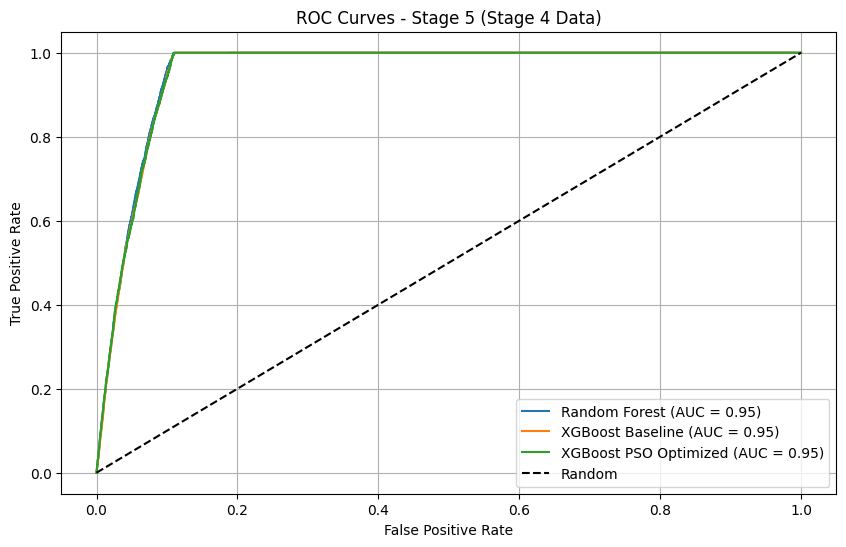

In [ ]:
print("Model Comparison:")
print("=" * 60)
print("\nRandom Forest ROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf))
print("XGBoost (Baseline) ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))
print("XGBoost (PSO Optimized) ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb_opt))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nXGBoost (Baseline) Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nXGBoost (PSO Optimized) Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_opt))

# ROC curves
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
fpr_xgb_opt, tpr_xgb_opt, _ = roc_curve(y_test, y_pred_proba_xgb_opt)

plt.figure(figsize=(10, 6))
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = ' + str(roc_auc_score(y_test, y_pred_proba_rf))[:4] + ')')
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost Baseline (AUC = ' + str(roc_auc_score(y_test, y_pred_proba_xgb))[:4] + ')')
plt.plot(fpr_xgb_opt, tpr_xgb_opt, label='XGBoost PSO Optimized (AUC = ' + str(roc_auc_score(y_test, y_pred_proba_xgb_opt))[:4] + ')')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Stage 5 (Stage 4 Data)')
plt.legend()
plt.grid(True)
plt.show()


## Feature Importance


Top 15 Most Important Features:
            feature  rf_importance  xgb_baseline_importance  \
2       z_score_abs       0.598849                 0.946254   
1           z_score       0.288194                 0.004023   
6      z_score_ma_5       0.059745                 0.005777   
7     z_score_std_5       0.031084                 0.005371   
5      spread_std_5       0.006677                 0.004132   
11  correlation_60d       0.003511                 0.005389   
10       return2_1d       0.002261                 0.004089   
0            spread       0.002222                 0.005617   
8      spread_ma_10       0.001991                 0.005569   
4       spread_ma_5       0.001946                 0.005001   
9        return1_1d       0.001804                 0.003655   
3       hedge_ratio       0.001717                 0.005123   

    xgb_optimized_importance  
2                   0.970072  
1                   0.002210  
6                   0.002769  
7                   0.00

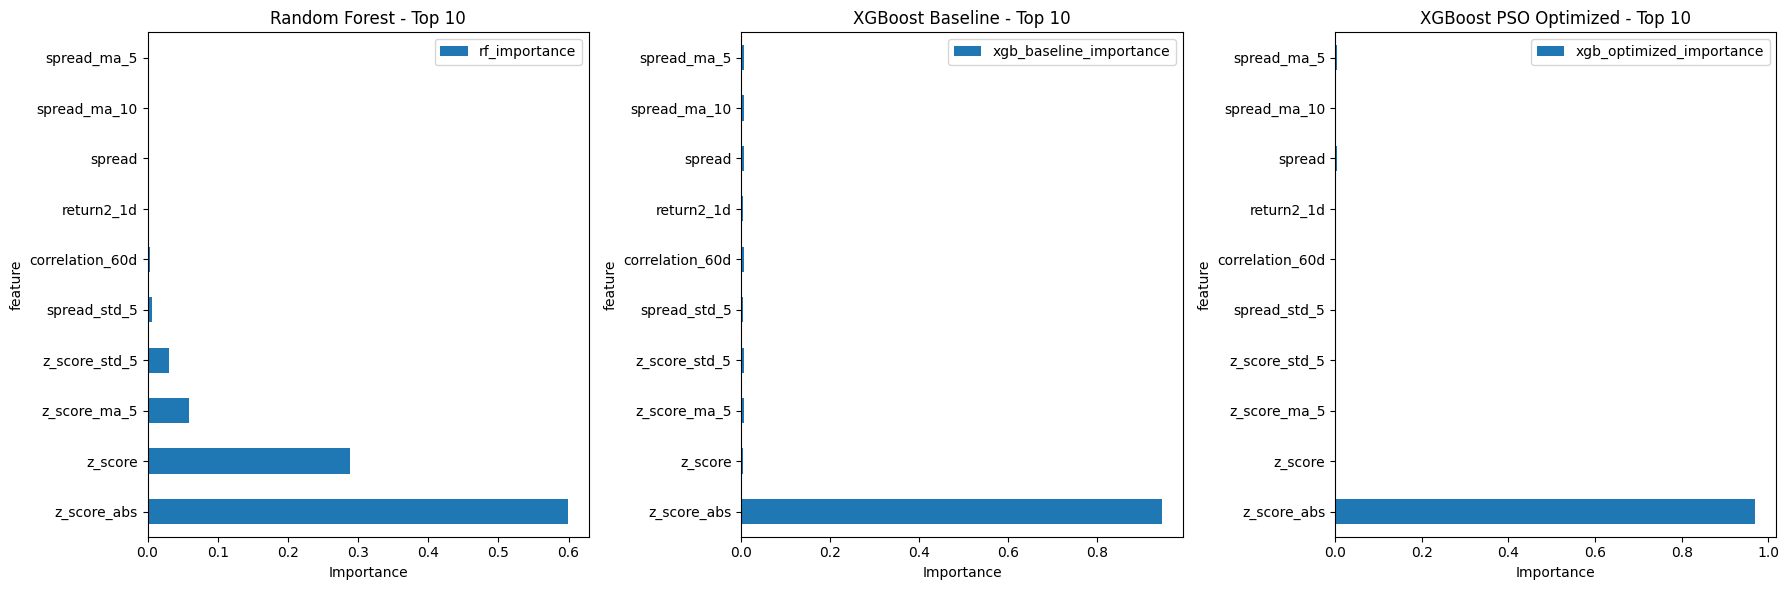


Saved feature importance to: ./dataset/stage5_stage4_feature_importance.csv


In [ ]:
feature_importance = pd.DataFrame({
    'feature': X_features_clean.columns,
    'rf_importance': rf.feature_importances_,
    'xgb_baseline_importance': xgb_model.feature_importances_,
    'xgb_optimized_importance': xgb_optimized.feature_importances_
}).sort_values('rf_importance', ascending=False)

print("Top 15 Most Important Features:")
print(feature_importance.head(15))

# Plot feature importance
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

feature_importance.head(10).plot(x='feature', y='rf_importance', kind='barh', ax=axes[0], title='Random Forest - Top 10')
axes[0].set_xlabel('Importance')

feature_importance.head(10).plot(x='feature', y='xgb_baseline_importance', kind='barh', ax=axes[1], title='XGBoost Baseline - Top 10')
axes[1].set_xlabel('Importance')

feature_importance.head(10).plot(x='feature', y='xgb_optimized_importance', kind='barh', ax=axes[2], title='XGBoost PSO Optimized - Top 10')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

# Save feature importance
feature_importance.to_csv('./dataset/stage5_stage4_feature_importance.csv', index=False)
print("\nSaved feature importance to: ./dataset/stage5_stage4_feature_importance.csv")


## Save Results


In [ ]:
results_df = pd.DataFrame({
    'actual': y_test.values,
    'rf_pred': y_pred_rf,
    'rf_proba': y_pred_proba_rf,
    'xgb_baseline_pred': y_pred_xgb,
    'xgb_baseline_proba': y_pred_proba_xgb,
    'xgb_optimized_pred': y_pred_xgb_opt,
    'xgb_optimized_proba': y_pred_proba_xgb_opt
})

results_df.to_csv('./dataset/stage5_stage4_predictions.csv', index=False)
print("Saved predictions to: ./dataset/stage5_stage4_predictions.csv")

best_params_df = pd.DataFrame({
    'parameter': ['max_depth', 'n_estimators', 'learning_rate', 'min_child_weight'],
    'value': [int(best_params_xgb[0]), int(best_params_xgb[1]), best_params_xgb[2], best_params_xgb[3]],
    'best_cv_f1_score': [best_score_xgb, best_score_xgb, best_score_xgb, best_score_xgb]
})
best_params_df.to_csv('./dataset/stage5_stage4_optimized_params.csv', index=False)
print("Saved optimized hyperparameters to: ./dataset/stage5_stage4_optimized_params.csv")

joblib.dump(rf, './dataset/stage5_rf_model.pkl')
joblib.dump(xgb_optimized, './dataset/stage5_xgb_optimized_model.pkl')
print("Saved trained models to ./dataset/stage5_rf_model.pkl and ./dataset/stage5_xgb_optimized_model.pkl")

print("\nStage 5 Summary (Using Stage 4 Data):")
print("=" * 60)
print("Pairs processed:", len(all_features))
print("Total samples:", len(X_features_clean))
print("Positive labels:", y.sum(), "(" + str(y.mean()*100) + "%)")
print("\nModel Performance:")
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf))
print("XGBoost Baseline ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))
print("XGBoost PSO Optimized ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb_opt))
print("\nOptimized Hyperparameters:")
print("  max_depth:", int(best_params_xgb[0]))
print("  n_estimators:", int(best_params_xgb[1]))
print("  learning_rate:", best_params_xgb[2])
print("  min_child_weight:", best_params_xgb[3])


Saved predictions to: ./dataset/stage5_stage4_predictions.csv
Saved optimized hyperparameters to: ./dataset/stage5_stage4_optimized_params.csv
Saved trained models to ./dataset/stage5_rf_model.pkl and ./dataset/stage5_xgb_optimized_model.pkl

Stage 5 Summary (Using Stage 4 Data):
Pairs processed: 100
Total samples: 390500
Positive labels: 9188 (2.3528809218950064%)

Model Performance:
Random Forest ROC-AUC: 0.956696962677326
XGBoost Baseline ROC-AUC: 0.9555841894517602
XGBoost PSO Optimized ROC-AUC: 0.9558862021156941

Optimized Hyperparameters:
  max_depth: 9
  n_estimators: 112
  learning_rate: 0.018734571931035282
  min_child_weight: 7.684277471553414
